# Experiment 1 — High-Dimensional Mode Coverage on a CIFAR-10 Gaussian Mixture

This notebook runs **Score-Repellent MCMC (SR-MCMC)** on a 1,000-mode
Gaussian Mixture whose centers are 1,000 CIFAR-10 images (100 per class).

- Target distribution: mixture of 1,000 Gaussians centered at CIFAR-10 images
- 50 parallel chains, all starting from the same initial mode (mode 0)
- Metric: cumulative number of unique modes discovered over MCMC steps

All randomness (Python, NumPy, PyTorch CPU/GPU, cuDNN) is seeded for reproducibility.


## 1. Imports and Global Configuration

In [6]:
import os
import random
import pickle

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision.datasets import CIFAR10
from torchvision import transforms
from tqdm import tqdm
from collections import defaultdict

# ---------------------------------------------------------------
# Reproducibility: fix all relevant seeds
# ---------------------------------------------------------------
SEED = 21
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ---------------------------------------------------------------
# Experiment hyperparameters
# ---------------------------------------------------------------
NUM_MODES         = 1000    # number of anchor images (modes)
IMAGES_PER_CLASS  = 100     # 100 images per class (10 classes)
SIGMA             = 4       # Gaussian std (controls mode separation)
STEP_SIZE         = 1.0     # Langevin step size
NOISE_SCALE       = 1.0     # noise scale for Langevin diffusion
BATCH_SIZE        = 50      # parallel chains

# SR-MCMC specific
REPELLENT_ALPHA   = 0.15    # repulsion strength alpha
REPELLENT_C       = 1e-3    # finite-difference bandwidth c
GAMMA_C           = 1.0     # coefficient for gamma schedule
GAMMA_RHO         = 0.6     # exponent for gamma schedule

# Loop control
STEPS_PER_ITER    = 5000
TARGET_MODES      = 1000    # stop once all 1000 modes are discovered
MAX_ITERATIONS    = 10      # hard cap on outer iterations
RECORD_INTERVAL   = 5       # store mode index every N steps

CIFAR10_CLASSES = ["airplane", "automobile", "bird", "cat", "deer",
                   "dog", "frog", "horse", "ship", "truck"]

print(f"\nModes: {NUM_MODES} | Sigma: {SIGMA} | Batch size: {BATCH_SIZE}")
print(f"SR-MCMC alpha: {REPELLENT_ALPHA}, c: {REPELLENT_C}, gamma: {GAMMA_C}/(n+1)^{GAMMA_RHO}")


Using device: cuda

Modes: 1000 | Sigma: 4 | Batch size: 50
SR-MCMC alpha: 0.15, c: 0.001, gamma: 1.0/(n+1)^0.6


## 2. Load CIFAR-10 and Select 1,000 Anchor Images

Files already downloaded and verified
CIFAR-10 training set size: 50000
Image shape: torch.Size([3, 32, 32])

Anchor images shape:   torch.Size([1000, 3, 32, 32])
Class distribution:    [100 100 100 100 100 100 100 100 100 100]


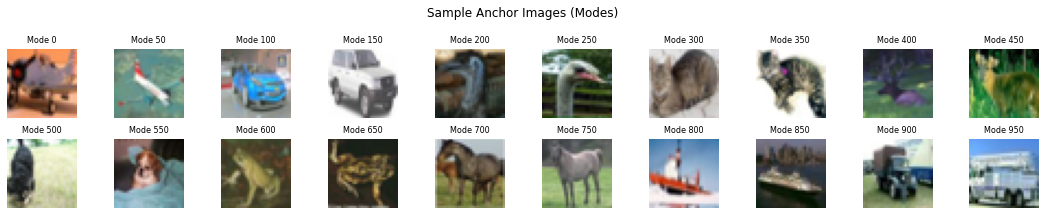

In [3]:
# CIFAR-10 is auto-downloaded by torchvision into ./data/
transform = transforms.Compose([transforms.ToTensor()])
cifar10_train = CIFAR10(root="../ebm_code_release/data", train=True, download=True, transform=transform)

print(f"CIFAR-10 training set size: {len(cifar10_train)}")
print(f"Image shape: {cifar10_train[0][0].shape}")

# Group images by class
images_by_class = defaultdict(list)
for idx in range(len(cifar10_train)):
    img, label = cifar10_train[idx]
    images_by_class[label].append(img)

anchor_images, anchor_labels = [], []
for class_idx in range(10):
    class_images = images_by_class[class_idx]
    selected = np.random.choice(len(class_images), IMAGES_PER_CLASS, replace=False)
    for j in selected:
        anchor_images.append(class_images[j])
        anchor_labels.append(class_idx)

anchor_images = torch.stack(anchor_images).to(device)          # (1000, 3, 32, 32)
anchor_labels = torch.tensor(anchor_labels).to(device)
anchor_images_flat = anchor_images                              # keep (N,C,H,W)

print(f"\nAnchor images shape:   {anchor_images.shape}")
print(f"Class distribution:    {np.bincount(anchor_labels.cpu().numpy())}")

# Visualise a few anchors
fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for i in range(20):
    r, c = divmod(i, 10)
    img = anchor_images[i * 50].cpu().permute(1, 2, 0).numpy()
    axes[r, c].imshow(img)
    axes[r, c].axis("off")
    axes[r, c].set_title(f"Mode {i*50}", fontsize=8)
plt.suptitle("Sample Anchor Images (Modes)")
plt.tight_layout()
plt.show()


## 3. GMM Score and Mode-Assignment Utilities

For a Gaussian mixture with equal weights and identical variance $\sigma^2 I$, the score is

$$\nabla_x \log p(x) = \sum_{i=1}^{M} w_i(x)\,\frac{\mu_i - x}{\sigma^2},
\qquad w_i(x) \propto \exp\!\left(-\frac{\lVert x-\mu_i\rVert^2}{2\sigma^2}\right).$$

We precompute anchor norms and their transpose once to make each step memory-efficient.


In [4]:
def build_mus_cache(mus):
    """Precompute cached quantities for pairwise distance / score."""
    if mus.dim() == 4:
        M = mus.shape[0]
        mus_flat = mus.view(M, -1).contiguous()
    else:
        mus_flat = mus.contiguous()
    mus_T = mus_flat.t().contiguous()
    mus_norm2 = (mus_flat * mus_flat).sum(dim=1)
    return {"mus_flat": mus_flat, "mus_T": mus_T, "mus_norm2": mus_norm2}


def pairwise_dist2_flat(x_flat, cache):
    x_flat = x_flat.contiguous()
    x_norm2 = (x_flat * x_flat).sum(dim=1, keepdim=True)
    return x_norm2 + cache["mus_norm2"].unsqueeze(0) - 2.0 * (x_flat @ cache["mus_T"])


def compute_score_fast_img(x_img, cache, sigma):
    """Score of GMM at image-shaped inputs (B,C,H,W)."""
    B = x_img.shape[0]
    x_flat = x_img.view(B, -1).contiguous()
    dist2 = pairwise_dist2_flat(x_flat, cache)
    log_probs = -0.5 * dist2 / (sigma ** 2)
    w = torch.softmax(log_probs, dim=1)
    mu_bar = w @ cache["mus_flat"]
    score_flat = (mu_bar - x_flat) / (sigma ** 2)
    return score_flat.view_as(x_img)


@torch.no_grad()
def assign_mode_fast_img(x_img, cache):
    """Return index of nearest anchor for each input."""
    B = x_img.shape[0]
    x_flat = x_img.view(B, -1).contiguous()
    dist2 = pairwise_dist2_flat(x_flat, cache)
    return dist2.argmin(dim=1)


## 4. Run SR-MCMC Until All Modes Are Discovered

The sampler uses the finite-difference Hessian-vector trick to build a surrogate score
$\tilde s(x) = s(x) + \alpha\,H(x)\theta$, with $\theta$ updated by an exponential moving
average of the score history. 50 chains start at mode 0.


In [ ]:
# Re-seed right before the sampling loop so the notebook is deterministic
# even if earlier cells are re-run in a different order.
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

cache = build_mus_cache(anchor_images_flat)

# All 50 chains start at Mode 0
x0 = anchor_images_flat[0].clone()
x_sr = x0.unsqueeze(0).repeat(BATCH_SIZE, 1, 1, 1)
theta_sr = torch.zeros_like(x_sr)
step_counter_sr = 0

seen_modes_sr = set()
sr_coverage_checkpoints = []
sr_mode_history = []

print("Starting SR-MCMC from Mode 0")
print(f"Initial class: {CIFAR10_CLASSES[anchor_labels[0].item()]}")
print(f"Target: {TARGET_MODES} modes (union over all {BATCH_SIZE} chains)")
print("=" * 80)

iteration = 0
sr_unique_modes = 0

while sr_unique_modes < TARGET_MODES and iteration < MAX_ITERATIONS:
    iteration += 1
    step_lo = (iteration - 1) * STEPS_PER_ITER + 1
    step_hi = iteration * STEPS_PER_ITER
    print(f"\nITERATION {iteration} (Steps {step_lo} - {step_hi})")

    for t in tqdm(range(STEPS_PER_ITER), desc="SR-MCMC (Batch)"):
        score_x = compute_score_fast_img(x_sr, cache, SIGMA)

        x_perturbed = x_sr + REPELLENT_C * theta_sr
        score_perturbed = compute_score_fast_img(x_perturbed, cache, SIGMA)
        H_theta = (score_x - score_perturbed) / REPELLENT_C

        score_surrogate = score_x + REPELLENT_ALPHA * H_theta
        noise = torch.randn_like(x_sr) * NOISE_SCALE * np.sqrt(2 * STEP_SIZE)
        x_new = x_sr + STEP_SIZE * score_surrogate + noise

        score_new = compute_score_fast_img(x_new, cache, SIGMA)
        gamma = max(GAMMA_C / ((step_counter_sr + 1) ** GAMMA_RHO), 0.5)
        theta_sr = theta_sr + gamma * (score_new - theta_sr)

        x_sr = x_new
        step_counter_sr += 1

        mode_idx_batch = assign_mode_fast_img(x_sr, cache)
        seen_modes_sr.update(mode_idx_batch.detach().cpu().tolist())

        if t % RECORD_INTERVAL == 0:
            sr_mode_history.extend(mode_idx_batch.detach().cpu().tolist())

        if len(seen_modes_sr) >= TARGET_MODES:
            break

    sr_unique_modes = len(seen_modes_sr)
    sr_coverage_checkpoints.append(sr_unique_modes)
    total_steps = iteration * STEPS_PER_ITER
    print(f"Checkpoint after {total_steps:,} steps: SR-MCMC discovered {sr_unique_modes} modes")

    if sr_unique_modes >= TARGET_MODES:
        print(f"\nTARGET REACHED: {sr_unique_modes} unique modes in {total_steps:,} steps")
        break

print("=" * 80)
print("FINAL SR-MCMC RESULTS")
print(f"Iterations: {iteration} | Steps: {iteration * STEPS_PER_ITER:,}")
print(f"SR-MCMC coverage: {len(seen_modes_sr)} / {NUM_MODES} modes "
      f"({len(seen_modes_sr)/NUM_MODES*100:.1f}%)")


Starting SR-MCMC from Mode 0
Initial class: airplane
Target: 1000 modes (union over all 50 chains)

ITERATION 1 (Steps 1 - 5000)


SR-MCMC (Batch):  18%|█▊        | 925/5000 [00:00<00:04, 1017.32it/s]

Checkpoint after 5,000 steps: SR-MCMC discovered 1000 modes

TARGET REACHED: 1000 unique modes in 5,000 steps
FINAL SR-MCMC RESULTS
Iterations: 1 | Steps: 5,000
SR-MCMC coverage: 1000 / 1000 modes (100.0%)


## 5. Figure 1 — Cumulative Mode Coverage

In [ ]:
def cumulative_unique_modes(mode_history, batch_size):
    seen, cum = set(), []
    for i in range(0, len(mode_history), batch_size):
        seen.update(mode_history[i:i + batch_size])
        cum.append(min(len(seen), NUM_MODES))
    return np.array(cum)


sr_cum = cumulative_unique_modes(sr_mode_history, BATCH_SIZE)
sr_steps = np.arange(1, len(sr_cum) + 1) * RECORD_INTERVAL

plt.figure(figsize=(12, 7))
plt.plot(sr_steps, sr_cum, label="SRMC", linewidth=2.5, color="blue")
plt.axhline(y=NUM_MODES, linestyle="--", color="gray",
            label=f"Total modes ({NUM_MODES})")
plt.xlabel("MCMC Steps", fontsize=24)
plt.ylabel("Cumulative Unique Modes", fontsize=24)
plt.title("SR-MCMC Mode Coverage", fontsize=26, fontweight="bold")
plt.legend(fontsize=18, loc="center right")
plt.tick_params(axis="both", labelsize=18)
plt.grid(True, alpha=0.3)
plt.xlim(0, sr_steps[-1])
plt.ylim(0, NUM_MODES * 1.05)
sr_final = min(int(sr_cum[-1]), NUM_MODES)
plt.text(sr_steps[-1] * 0.5, NUM_MODES * 0.65,
         f"SRMC: {sr_final} modes ({sr_final/NUM_MODES*100:.1f}%)",
         fontsize=18, fontweight="bold", color="blue")
plt.tight_layout()
plt.savefig("mode_coverage_main.pdf", dpi=300, bbox_inches="tight")
plt.show()


## 6. Figure 2 — Mode Hopping Pattern

In [ ]:
sr_num_records = len(sr_mode_history) // BATCH_SIZE
sr_scatter_steps = np.repeat(np.arange(1, sr_num_records + 1) * RECORD_INTERVAL, BATCH_SIZE)

fig, ax = plt.subplots(figsize=(14, 5))
ax.scatter(sr_scatter_steps[:14000], sr_mode_history[:14000], s=1, alpha=0.5, color="blue")
ax.set_xlabel("MCMC Step", fontsize=24)
ax.set_ylabel("Mode Index", fontsize=24)
ax.set_title("SRMC: Mode Hopping Pattern", fontsize=26, fontweight="bold")
ax.set_ylim(-50, NUM_MODES + 50)
ax.axhline(y=0, color="red", linestyle="--", linewidth=1, alpha=0.5, label="Initial Mode")
ax.legend(fontsize=18, loc="upper right")
ax.tick_params(axis="both", labelsize=18)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("mode_hopping_pattern.pdf", dpi=300, bbox_inches="tight")
plt.show()


## 7. Figure 3 — Mode Visit Histogram

In [ ]:
sr_mode_counts = np.bincount(sr_mode_history, minlength=NUM_MODES)

plt.figure(figsize=(14, 5))
plt.bar(range(NUM_MODES), sr_mode_counts, color="blue", alpha=0.7, width=1.0)
plt.xlabel("Mode Index", fontsize=14)
plt.ylabel("Visit Count", fontsize=14)
plt.title(f"SR-MCMC Mode Visit Distribution "
          f"({int(np.sum(sr_mode_counts > 0))} / {NUM_MODES} modes visited)",
          fontsize=16, fontweight="bold")
plt.xlim(0, NUM_MODES)
plt.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("mode_visit_histogram.pdf", dpi=300, bbox_inches="tight")
plt.show()


## 8. Figure 4 — Per-Class Mode Coverage

In [ ]:
def compute_class_coverage(mode_history, labels, num_classes=10):
    visited = set(mode_history)
    out = np.zeros(num_classes)
    for m in visited:
        out[labels[m].item()] += 1
    return out


sr_class_coverage = compute_class_coverage(sr_mode_history, anchor_labels)

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(10)
ax.bar(x, sr_class_coverage, color="blue", alpha=0.8, label="SR-MCMC")
ax.axhline(y=IMAGES_PER_CLASS, color="gray", linestyle="--",
           label=f"Total per class ({IMAGES_PER_CLASS})")
ax.set_xlabel("CIFAR-10 Class", fontsize=14)
ax.set_ylabel(f"Modes Visited (out of {IMAGES_PER_CLASS})", fontsize=14)
ax.set_title("Per-Class Mode Coverage — SR-MCMC", fontsize=16, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(CIFAR10_CLASSES, rotation=45, ha="right")
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3, axis="y")
ax.set_ylim(0, IMAGES_PER_CLASS * 1.1)

for rect in ax.patches:
    h = rect.get_height()
    if h > 0:
        ax.text(rect.get_x() + rect.get_width() / 2, h, f"{int(h)}",
                ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.savefig("class_coverage.pdf", dpi=300, bbox_inches="tight")
plt.show()

print("Per-class coverage:")
for i, cname in enumerate(CIFAR10_CLASSES):
    print(f"  {cname:12s}: {int(sr_class_coverage[i]):3d} / {IMAGES_PER_CLASS}")


## 9. Save Summary

In [ ]:
summary = {
    "sr_final_coverage": int(len(seen_modes_sr)),
    "sr_class_coverage": sr_class_coverage.tolist(),
    "steps": int(iteration * STEPS_PER_ITER),
    "seed": SEED,
    "config": {
        "num_modes": NUM_MODES, "sigma": SIGMA, "step_size": STEP_SIZE,
        "noise_scale": NOISE_SCALE, "batch_size": BATCH_SIZE,
        "alpha": REPELLENT_ALPHA, "c": REPELLENT_C,
        "gamma_c": GAMMA_C, "gamma_rho": GAMMA_RHO,
    },
}
with open("experiment_summary.pkl", "wb") as f:
    pickle.dump(summary, f)
print("Summary saved to experiment_summary.pkl")
